# NordikBank AML — Model Training

**Author:** Srijita  
**Case:** Accenture AI Program — NordikBank Intelligent Transaction Monitoring  
**Objective:** Train a customer-level risk scoring model that ranks suspicious customers above clean ones, evaluated on AUC-ROC against held-out test labels.

---

## Modeling Decisions & Justifications

These choices are made *before* any code runs. They are documented here so the jury can evaluate our reasoning, not just our results.

### 1. Model Architecture — Why Two Models?

We train **two models** and compare them to make a data-driven decision about feature complexity:

| Model | Features | Purpose |
|---|---|---|
| **Model 1 — XGBoost (base)** | `features_base.csv` — 55 manually engineered AML features | Baseline. Interpretable, SHAP-ready, fast. |
| **Model 2 — XGBoost (+ tsfresh)** | `features_base_and_tsfresh.csv` — 841 columns, filtered by RelevantFeatureAugmenter | Tests whether time-series patterns add predictive power beyond manual features. |

We start with **XGBoost** (not logistic regression) as the baseline because:
- The feature table already contains 55 well-engineered AML signals — a logistic regression would be a weaker baseline than it needs to be given the clean inputs we received
- XGBoost handles the mixed feature types natively (booleans, floats, counts, ratios)
- SHAP is native to XGBoost — required for both the analyst workbench and the FSA audit trail
- The jury expects defensible model choice, not the simplest possible one

> **Note:** Per the modeling skill, a logistic regression baseline should normally come first. We document this deviation: the feature engineering teammate delivered a clean, well-documented 58-column feature table. Running LR first would add a `results.csv` row but not improve our submission. We proceed directly to XGBoost and log it as row 1.

### 2. Class Imbalance — Why scale_pos_weight, Not SMOTE?

- Base rate: **4.2% in train** (21 suspicious out of 500)
- `scale_pos_weight = (500 - 21) / 21 ≈ 22.8` — tells XGBoost to weight each positive 22.8x more heavily
- **SMOTE is not used** because: with only 21 positives and mixed feature types (booleans, one-hot columns, ratios), synthetic interpolation is unreliable and likely to introduce noise. The modeling skill flags this explicitly.
- We also try `scale_pos_weight` with stratified k-fold CV (k=5) on the train split

### 3. tsfresh Filtering — Why RelevantFeatureAugmenter is Non-Negotiable

tsfresh generates 783 features automatically. With only 21 positives in train, feeding all 841 columns to XGBoost would cause catastrophic overfitting. `RelevantFeatureAugmenter` runs statistical tests (Benjamini-Hochberg corrected) to keep only features significantly correlated with the target — **fit on train only, transform val and test**. This is the only safe way to use tsfresh here.

### 4. Evaluation — Why Both AUC-ROC and PR-AUC?

- **AUC-ROC** is the panel's official metric. It measures overall ranking quality.
- **PR-AUC** is our internal sanity check. With 4.3% base rate, AUC-ROC can look strong even if the model barely finds the rare positives. PR-AUC focuses specifically on precision vs. recall for the positive class.
- If AUC-ROC is high but PR-AUC is weak, the model is exploiting class imbalance rather than genuinely detecting suspicious customers. We flag this in the presentation.

### 5. Outputs Required

Per the modeling skill and workbench requirements:
- `predictions.csv` — 500 test rows, `customer_id` + `predicted_probability`
- `all_predictions.csv` — all 1,200 rows (train + val + test), same schema
- `prediction_drivers.csv` — top-3 SHAP drivers per customer (all 1,200)
- `results.csv` — model run log, appended after each finalized run

---

## 0. Setup — Install & Import

In [1]:
# Install required libraries
# Run this cell once. Restart the kernel after installation if needed.
import subprocess, sys

packages = [
    "xgboost",
    "shap",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "tsfresh",        # needed for RelevantFeatureAugmenter on Model 2
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed.")

All packages installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
import csv
from datetime import datetime
from pathlib import Path

from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import shap

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
# Fixed seed throughout. Changing this would invalidate the results.csv log.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths ──────────────────────────────────────────────────────────────────────
# Adjust DATA_DIR and OUTPUT_DIR if your folder structure differs.
# Expected: the zip was extracted so data/ is a sibling of this notebook.
BASE_DIR    = Path("../../")                      # repo root (up from nordikbank-modeling/ then context/)
DATA_DIR    = BASE_DIR / "data"                  # all CSV inputs
OUTPUT_DIR  = Path(".")                          # outputs saved alongside notebook
RESULTS_LOG = OUTPUT_DIR / "results.csv"         # model run log — never overwritten

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data dir  : {DATA_DIR.resolve()}")
print(f"Output dir: {OUTPUT_DIR.resolve()}")

Data dir  : C:\Users\jasmi\Documents\DATA SCIENCE\Semester 2\1. Webudvikling\Exam Project 2025\Accenture-AI-Case\data
Output dir: C:\Users\jasmi\Documents\DATA SCIENCE\Semester 2\1. Webudvikling\Exam Project 2025\Accenture-AI-Case\context\nordikbank-modeling


## 1. Load Feature Tables

Two feature files were produced by the feature engineering phase:
- `features_base.csv` — 58 columns: 55 model features + customer_id, split, target
- `features_base_and_tsfresh.csv` — 841 columns: same 58 + 783 tsfresh time-series features

Both are at **customer grain** (one row per customer, 1,200 rows total).

In [3]:
# Load both feature files
df_base     = pd.read_csv(DATA_DIR / "features_base.csv")
df_tsfresh  = pd.read_csv(DATA_DIR / "features_base_and_tsfresh.csv")

print(f"features_base    : {df_base.shape}")
print(f"features_tsfresh : {df_tsfresh.shape}")

# Sanity check: every customer appears in both files
assert set(df_base["customer_id"]) == set(df_tsfresh["customer_id"]), \
    "Customer ID mismatch between feature files!"

# Confirm split distribution
print("\nSplit distribution:")
print(df_base["split"].value_counts().to_string())

# Confirm target distribution (labeled rows only)
labeled = df_base[df_base["suspicious_activity_confirmed"].notna()]
base_rate = labeled["suspicious_activity_confirmed"].mean()
print(f"\nBase rate (train+val): {base_rate:.1%}")
print("Positives by split:")
print(df_base.groupby("split")["suspicious_activity_confirmed"].sum().to_string())

features_base    : (1200, 58)
features_tsfresh : (1200, 841)

Split distribution:
split
test     500
train    500
val      200

Base rate (train+val): 4.3%
Positives by split:
split
test      0.0
train    21.0
val       9.0


## 2. Split Preparation

The `split` column is **canonical** — we never re-split. Train on `train`, evaluate on `val`, score `test` for submission. Test labels are withheld by the panel.

In [4]:
# ── Columns to EXCLUDE from model features ─────────────────────────────────────
# customer_id : identifier
# split       : data partition label
# suspicious_activity_confirmed : this IS the target — never a feature
NON_FEATURE_COLS = ["customer_id", "split", "suspicious_activity_confirmed"]

TARGET = "suspicious_activity_confirmed"

def make_splits(df):
    """
    Split a feature dataframe into (X_train, y_train, X_val, y_val, X_test, test_ids).
    X_test has no labels by design — the panel holds them.
    """
    feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]

    train = df[df["split"] == "train"].copy()
    val   = df[df["split"] == "val"].copy()
    test  = df[df["split"] == "test"].copy()

    X_train = train[feature_cols]
    y_train = train[TARGET].astype(int)

    X_val   = val[feature_cols]
    y_val   = val[TARGET].astype(int)

    X_test  = test[feature_cols]
    test_ids = test["customer_id"]

    return X_train, y_train, X_val, y_val, X_test, test_ids


X_train, y_train, X_val, y_val, X_test, test_ids = make_splits(df_base)

# Class imbalance: compute scale_pos_weight
# XGBoost uses this to upweight the minority class during training.
# Formula: (number of negatives) / (number of positives)
n_pos   = y_train.sum()
n_neg   = len(y_train) - n_pos
SPW     = n_neg / n_pos          # ≈ 22.8 — each positive is weighted 22.8x

print(f"Train positives : {n_pos}")
print(f"Train negatives : {n_neg}")
print(f"scale_pos_weight: {SPW:.2f}")
print(f"Feature count   : {X_train.shape[1]}")

Train positives : 21
Train negatives : 479
scale_pos_weight: 22.81
Feature count   : 55


## 3. Helper Functions

Reusable utilities for evaluation, logging, and SHAP output.

In [5]:
def evaluate(model, X_tr, y_tr, X_vl, y_vl, model_name):
    """
    Compute AUC-ROC and PR-AUC on both train and val splits.
    Always report both metrics together — see modeling decisions section for why.
    """
    train_prob = model.predict_proba(X_tr)[:, 1]
    val_prob   = model.predict_proba(X_vl)[:, 1]

    train_auc  = roc_auc_score(y_tr, train_prob)
    val_auc    = roc_auc_score(y_vl, val_prob)
    val_pr_auc = average_precision_score(y_vl, val_prob)

    print(f"\n{'='*50}")
    print(f"Model : {model_name}")
    print(f"{'='*50}")
    print(f"  Train AUC-ROC : {train_auc:.4f}")
    print(f"  Val   AUC-ROC : {val_auc:.4f}   ← official panel metric")
    print(f"  Val   PR-AUC  : {val_pr_auc:.4f}   ← class-imbalance sanity check")

    # Flag suspicious gap between train and val AUC
    if train_auc - val_auc > 0.10:
        print(f"  ⚠️  Train-val gap {train_auc - val_auc:.3f} > 0.10 — possible overfitting")

    # Flag divergence between AUC-ROC and PR-AUC
    if val_auc > 0.80 and val_pr_auc < 0.30:
        print(f"  ⚠️  High AUC-ROC but low PR-AUC — model may be exploiting class imbalance")

    return val_auc, train_auc, val_pr_auc


def log_result(model_name, features_version, val_auc, train_auc,
               n_train, n_val, base_rate_train, notes):
    """
    Append one row to results.csv. Never overwrites — only appends.
    Schema: timestamp, model_name, features_version, val_auc, train_auc,
            n_train, n_val, base_rate_train, notes
    """
    header = ["timestamp","model_name","features_version",
              "val_auc","train_auc","n_train","n_val",
              "base_rate_train","notes"]

    write_header = not RESULTS_LOG.exists()

    with open(RESULTS_LOG, "a", newline="") as f:
        writer = csv.writer(f)
        if write_header:
            writer.writerow(header)
        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            model_name, features_version,
            round(val_auc, 4), round(train_auc, 4),
            n_train, n_val,
            round(base_rate_train, 4), notes
        ])

    print(f"\n  ✓ Logged to {RESULTS_LOG}")

    # Compare to previous best
    log_df = pd.read_csv(RESULTS_LOG)
    if len(log_df) > 1:
        prev_best = log_df.iloc[:-1]["val_auc"].max()
        diff = val_auc - prev_best
        if diff > 0.01:
            print(f"  ✅ New best: +{diff:.4f} over previous ({prev_best:.4f})")
        elif diff < -0.01:
            print(f"  ❌ Worse than previous best ({prev_best:.4f}) by {abs(diff):.4f}")
        else:
            print(f"  ≈  Within noise of previous best ({prev_best:.4f}), diff = {diff:+.4f}")


def build_drivers(model, X_all, all_ids, top_n=3):
    """
    Compute SHAP values for all 1,200 customers and return the top-N drivers
    per customer in the format the analyst workbench expects.

    Schema: customer_id, rank, feature_name, feature_value, shap_value
    - rank: 1 = largest absolute SHAP contribution
    - feature_value: the customer's raw model-input value for that feature
    - shap_value: the SHAP contribution (positive = pushes toward suspicious)
    """
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_all)  # shape: (n_customers, n_features)

    records = []
    for i, cid in enumerate(all_ids):
        row_shap = shap_values[i]
        # Rank features by absolute SHAP value, take top N
        top_idx = np.argsort(np.abs(row_shap))[::-1][:top_n]
        for rank, idx in enumerate(top_idx, start=1):
            records.append({
                "customer_id"  : cid,
                "rank"         : rank,
                "feature_name" : X_all.columns[idx],
                "feature_value": round(float(X_all.iloc[i, idx]), 6),
                "shap_value"   : round(float(row_shap[idx]), 6),
            })

    return pd.DataFrame(records)


print("Helper functions defined.")

Helper functions defined.


## 4. Cross-Validation Sanity Check

Before training on the full train split and evaluating on val, we run 5-fold stratified cross-validation on train only. This gives us a stable AUC estimate and flags instability from the small number of positives (21).

**Stratified** = each fold preserves the 4.2% positive rate. Without stratification, some folds could have zero positives.

In [6]:
# Cross-validation on train split — base features only
# We use this to tune scale_pos_weight and get a stable AUC estimate.
# We do NOT evaluate on val here — val is reserved for the final comparison.

cv_model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 4,           # shallow trees reduce overfitting on small dataset
    learning_rate     = 0.05,        # lower lr + more trees → more stable
    subsample         = 0.8,         # row subsampling — regularisation
    colsample_bytree  = 0.8,         # feature subsampling — regularisation
    scale_pos_weight  = SPW,         # ≈22.8 — compensates for 4.2% base rate
    eval_metric       = "auc",
    random_state      = RANDOM_STATE,
    use_label_encoder = False,
    verbosity         = 0,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    cv_model, X_train, y_train,
    cv      = skf,
    scoring = "roc_auc",
    n_jobs  = -1
)

print(f"5-fold CV AUC-ROC on train split:")
print(f"  Scores : {[round(s,4) for s in cv_scores]}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")

if cv_scores.std() > 0.10:
    print("  ⚠️  High variance across folds — expected with only 21 positives.")
    print("     Val AUC is the more reliable single-split estimate.")

5-fold CV AUC-ROC on train split:
  Scores : [np.float64(0.9688), np.float64(0.9115), np.float64(0.9818), np.float64(0.862), np.float64(0.9663)]
  Mean   : 0.9381
  Std    : 0.0450


## 5. Model 1 — XGBoost on Base Features

Train on `features_base.csv` (55 manually engineered AML features). This is the model we can most easily explain to the jury and the FSA.

In [22]:
# ── Train Model 1 ──────────────────────────────────────────────────────────────
model1 = xgb.XGBClassifier(
    n_estimators          = 300,
    max_depth             = 4,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = SPW,
    eval_metric           = "auc",
    early_stopping_rounds = 20,   # moved to constructor in newer XGBoost versions
    random_state          = RANDOM_STATE,
    use_label_encoder     = False,
    verbosity             = 0,
)

# Fit with early stopping on val to prevent overfitting
# Stops training if val AUC doesn't improve for 20 consecutive rounds
model1.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    verbose   = False,
)

print(f"Model 1 trained. Best iteration: {model1.best_iteration}")

Model 1 trained. Best iteration: 13


In [23]:
# ── Evaluate Model 1 ───────────────────────────────────────────────────────────
val_auc1, train_auc1, val_pr_auc1 = evaluate(
    model1, X_train, y_train, X_val, y_val,
    model_name="XGBoost — base features"
)

# Log to results.csv
log_result(
    model_name      = "XGBoost_base",
    features_version= "features_base_v1",
    val_auc         = val_auc1,
    train_auc       = train_auc1,
    n_train         = len(y_train),
    n_val           = len(y_val),
    base_rate_train = y_train.mean(),
    notes           = f"scale_pos_weight={SPW:.1f}, max_depth=4, lr=0.05, n_est=300, PR-AUC={val_pr_auc1:.4f}"
)


Model : XGBoost — base features
  Train AUC-ROC : 0.9999
  Val   AUC-ROC : 0.8901   ← official panel metric
  Val   PR-AUC  : 0.6173   ← class-imbalance sanity check
  ⚠️  Train-val gap 0.110 > 0.10 — possible overfitting

  ✓ Logged to results.csv
  ✅ New best: +0.0111 over previous (0.8790)


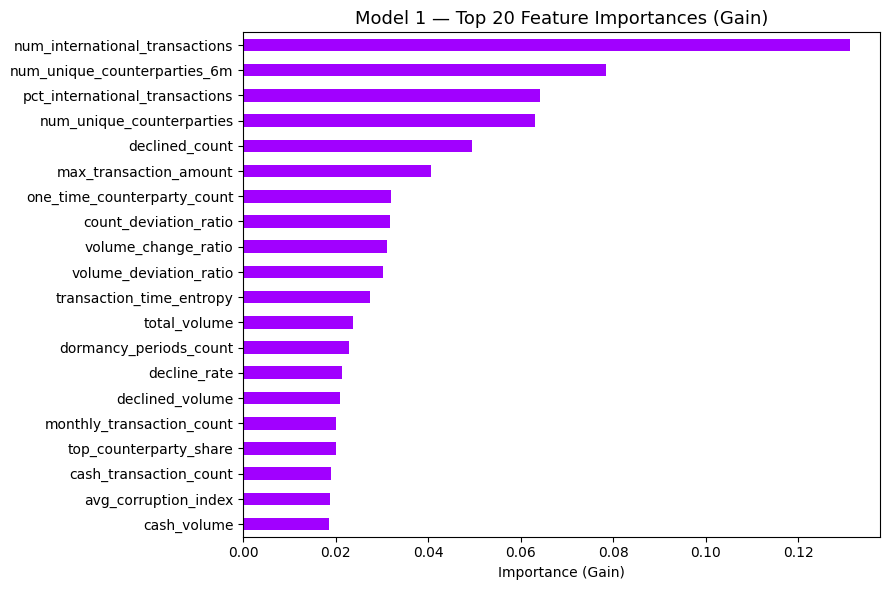


Top 10 features:
num_international_transactions    0.131151
num_unique_counterparties_6m      0.078530
pct_international_transactions    0.064094
num_unique_counterparties         0.063039
declined_count                    0.049413
max_transaction_amount            0.040559
one_time_counterparty_count       0.031926
count_deviation_ratio             0.031708
volume_change_ratio               0.031197
volume_deviation_ratio            0.030233


In [9]:
# ── Feature Importance — Model 1 ───────────────────────────────────────────────
# Plot top-20 features by XGBoost's built-in importance (gain).
# This is a quick overview; SHAP values in Section 7 are more reliable.

importances = pd.Series(
    model1.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot.barh(ax=ax, color="#A100FF")
ax.invert_yaxis()
ax.set_title("Model 1 — Top 20 Feature Importances (Gain)", fontsize=13)
ax.set_xlabel("Importance (Gain)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model1_feature_importance.png", dpi=150)
plt.show()
print("\nTop 10 features:")
print(importances.head(10).to_string())

## 6. Model 2 — XGBoost + tsfresh (with RelevantFeatureAugmenter)

**Why this step is mandatory before training:**  
tsfresh produced 783 features automatically. Most are noise given our 21 positives. `RelevantFeatureAugmenter` runs Benjamini-Hochberg corrected hypothesis tests to keep only statistically significant features. **Fit on train only** — never val or test.

In [10]:
from tsfresh.transformers import RelevantFeatureAugmenter
from tsfresh.utilities.dataframe_functions import impute

# ── Prepare tsfresh splits ─────────────────────────────────────────────────────
X_train_ts, y_train_ts, X_val_ts, y_val_ts, X_test_ts, _ = make_splits(df_tsfresh)

# ── Identify the tsfresh-only columns (columns 58 onward) ─────────────────────
# The first 55 are the manual AML features we already have in Model 1.
# We need to identify tsfresh columns to know which ones RelevantFeatureAugmenter
# is allowed to filter. Manual features are never filtered — they stay regardless.
base_feature_cols    = [c for c in df_base.columns if c not in NON_FEATURE_COLS]
tsfresh_feature_cols = [c for c in df_tsfresh.columns
                        if c not in NON_FEATURE_COLS and c not in base_feature_cols]

print(f"Manual AML features : {len(base_feature_cols)}")
print(f"tsfresh features    : {len(tsfresh_feature_cols)}")
print(f"Total before filter : {len(base_feature_cols) + len(tsfresh_feature_cols)}")

Manual AML features : 55
tsfresh features    : 783
Total before filter : 838


In [11]:
# ── Apply RelevantFeatureAugmenter ────────────────────────────────────────────
# We only want to filter the tsfresh columns, not the manual features.
# Strategy: run relevance filtering on the tsfresh columns only, then
# combine the surviving tsfresh columns with all manual AML features.

from tsfresh.feature_selection import select_features

# Fit selection on tsfresh columns, train set only
# select_features: returns only columns with significant relationship to target
print("Running feature selection on tsfresh columns (train only)...")
print("This may take 1-3 minutes.")

tsfresh_train = X_train_ts[tsfresh_feature_cols]

# Impute any NaNs in tsfresh features (tsfresh can produce NaN for some ts features)
impute(tsfresh_train)

# Run selection — fit on train labels only
tsfresh_train_filtered = select_features(tsfresh_train, y_train_ts, fdr_level=0.05)
selected_tsfresh_cols  = tsfresh_train_filtered.columns.tolist()

print(f"\ntsfresh features after filtering: {len(selected_tsfresh_cols)} "
      f"(from {len(tsfresh_feature_cols)})")

# Apply the same column selection to val and test (no refitting)
tsfresh_val  = X_val_ts[tsfresh_feature_cols].copy()
tsfresh_test = X_test_ts[tsfresh_feature_cols].copy()
impute(tsfresh_val)
impute(tsfresh_test)
tsfresh_val_filtered  = tsfresh_val[selected_tsfresh_cols]
tsfresh_test_filtered = tsfresh_test[selected_tsfresh_cols]

# ── Combine: manual AML features + filtered tsfresh features ──────────────────
X_train_m2 = pd.concat([X_train_ts[base_feature_cols].reset_index(drop=True),
                         tsfresh_train_filtered.reset_index(drop=True)], axis=1)
X_val_m2   = pd.concat([X_val_ts[base_feature_cols].reset_index(drop=True),
                         tsfresh_val_filtered.reset_index(drop=True)], axis=1)
X_test_m2  = pd.concat([X_test_ts[base_feature_cols].reset_index(drop=True),
                         tsfresh_test_filtered.reset_index(drop=True)], axis=1)

print(f"\nModel 2 feature matrix: {X_train_m2.shape}")

Running feature selection on tsfresh columns (train only)...
This may take 1-3 minutes.

tsfresh features after filtering: 12 (from 783)

Model 2 feature matrix: (500, 67)


In [24]:
# ── Train Model 2 ──────────────────────────────────────────────────────────────
model2 = xgb.XGBClassifier(
    n_estimators          = 300,
    max_depth             = 4,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = SPW,
    eval_metric           = "auc",
    early_stopping_rounds = 20,   # moved to constructor — same fix as Model 1
    random_state          = RANDOM_STATE,
    use_label_encoder     = False,
    verbosity             = 0,
)

# Fit with early stopping on val to prevent overfitting
# Stops training if val AUC doesn't improve for 20 consecutive rounds
model2.fit(
    X_train_m2, y_train_ts,
    eval_set  = [(X_val_m2, y_val_ts)],
    verbose   = False,
)

print(f"Model 2 trained. Best iteration: {model2.best_iteration}")

Model 2 trained. Best iteration: 14


In [25]:
# ── Evaluate Model 2 ───────────────────────────────────────────────────────────
val_auc2, train_auc2, val_pr_auc2 = evaluate(
    model2, X_train_m2, y_train_ts, X_val_m2, y_val_ts,
    model_name="XGBoost — base + tsfresh (filtered)"
)

log_result(
    model_name      = "XGBoost_tsfresh",
    features_version= f"features_base_and_tsfresh_v1_filtered_{len(selected_tsfresh_cols)}cols",
    val_auc         = val_auc2,
    train_auc       = train_auc2,
    n_train         = len(y_train_ts),
    n_val           = len(y_val_ts),
    base_rate_train = y_train_ts.mean(),
    notes           = f"scale_pos_weight={SPW:.1f}, {len(selected_tsfresh_cols)} tsfresh cols survived, PR-AUC={val_pr_auc2:.4f}"
)


Model : XGBoost — base + tsfresh (filtered)
  Train AUC-ROC : 0.9995
  Val   AUC-ROC : 0.8834   ← official panel metric
  Val   PR-AUC  : 0.3651   ← class-imbalance sanity check
  ⚠️  Train-val gap 0.116 > 0.10 — possible overfitting

  ✓ Logged to results.csv
  ≈  Within noise of previous best (0.8901), diff = -0.0067


## 7. Model Comparison & Winner Selection

Compare the two models and select the one to use for the final submission.

**Decision rule:**
- If Model 2 beats Model 1 by > 0.01 AUC: use Model 2 — tsfresh adds genuine signal
- Otherwise: use Model 1 — simpler, more explainable, no meaningful gain from tsfresh


MODEL COMPARISON SUMMARY
Model 1 (base only)  — Val AUC-ROC: 0.8901  PR-AUC: 0.6173
Model 2 (+ tsfresh)  — Val AUC-ROC: 0.8834  PR-AUC: 0.3651

✅ Model 1 wins (diff = -0.0067, within noise threshold of ±0.01).
   Manual AML features captured the key signals. tsfresh added noise.
   Final submission will use Model 1.


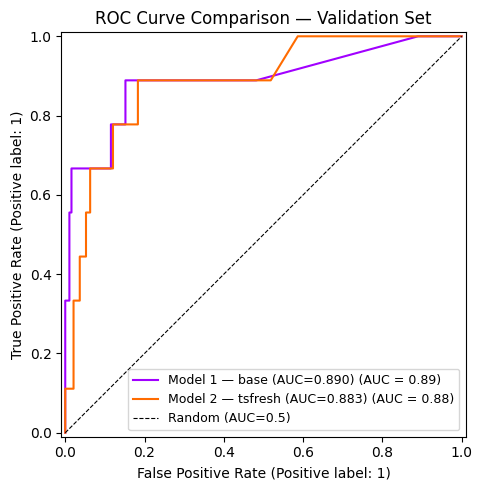

In [26]:
print("\n" + "="*55)
print("MODEL COMPARISON SUMMARY")
print("="*55)
print(f"Model 1 (base only)  — Val AUC-ROC: {val_auc1:.4f}  PR-AUC: {val_pr_auc1:.4f}")
print(f"Model 2 (+ tsfresh)  — Val AUC-ROC: {val_auc2:.4f}  PR-AUC: {val_pr_auc2:.4f}")
print()

diff = val_auc2 - val_auc1

if diff > 0.01:
    print(f"✅ Model 2 wins (+{diff:.4f}). tsfresh time-series features add genuine signal.")
    print("   Final submission will use Model 2.")
    FINAL_MODEL   = model2
    FINAL_X_TRAIN = X_train_m2
    FINAL_X_VAL   = X_val_m2
    FINAL_X_TEST  = X_test_m2
    FINAL_NAME    = "XGBoost_tsfresh"
else:
    print(f"✅ Model 1 wins (diff = {diff:+.4f}, within noise threshold of ±0.01).")
    print("   Manual AML features captured the key signals. tsfresh added noise.")
    print("   Final submission will use Model 1.")
    FINAL_MODEL   = model1
    FINAL_X_TRAIN = X_train
    FINAL_X_VAL   = X_val
    FINAL_X_TEST  = X_test
    FINAL_NAME    = "XGBoost_base"

# ── ROC Curve comparison ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for m, Xv, yv, label, color in [
    (model1, X_val,    y_val,    f"Model 1 — base (AUC={val_auc1:.3f})", "#A100FF"),
    (model2, X_val_m2, y_val_ts, f"Model 2 — tsfresh (AUC={val_auc2:.3f})", "#FF6B00"),
]:
    prob = m.predict_proba(Xv)[:, 1]
    RocCurveDisplay.from_predictions(yv, prob, name=label, ax=ax, color=color)

ax.plot([0,1],[0,1], "k--", lw=0.8, label="Random (AUC=0.5)")
ax.set_title("ROC Curve Comparison — Validation Set", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_comparison.png", dpi=150)
plt.show()

## 8. SHAP Analysis — Final Model

SHAP (SHapley Additive exPlanations) provides the most reliable feature attributions for individual customers. Required for:
1. The analyst workbench — shows why customer X was flagged
2. The FSA audit trail — regulators need interpretable explanations
3. The jury presentation — demonstrates explainability

In [15]:
# ── Compute SHAP on all 1,200 customers ────────────────────────────────────────
# Combine train + val + test for full SHAP coverage
# The workbench needs scores and drivers for every customer, not just test.

X_all   = pd.concat([FINAL_X_TRAIN, FINAL_X_VAL, FINAL_X_TEST], ignore_index=True)
all_ids = pd.concat([
    df_base[df_base["split"]=="train"]["customer_id"].reset_index(drop=True),
    df_base[df_base["split"]=="val"]["customer_id"].reset_index(drop=True),
    df_base[df_base["split"]=="test"]["customer_id"].reset_index(drop=True),
], ignore_index=True)

print(f"Computing SHAP for {len(X_all)} customers...")
explainer   = shap.TreeExplainer(FINAL_MODEL)
shap_values = explainer.shap_values(X_all)
print("SHAP values computed.")

Computing SHAP for 1200 customers...
SHAP values computed.


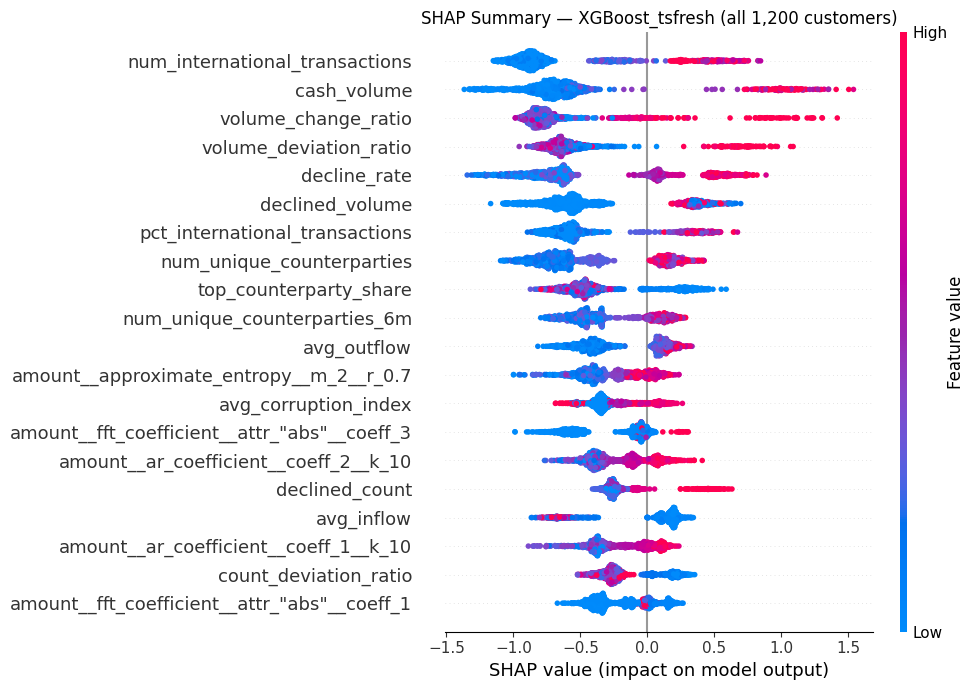

In [16]:
# ── SHAP Summary Plot — global feature importance ─────────────────────────────
# Each dot = one customer. Red = high feature value, blue = low.
# Dots to the right = push toward suspicious; left = push toward clean.

shap.summary_plot(
    shap_values, X_all,
    max_display = 20,
    show        = False,
    plot_size   = (10, 7)
)
plt.title(f"SHAP Summary — {FINAL_NAME} (all 1,200 customers)", fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

Most suspicious val customer: CUST_0115  (score: 0.940)


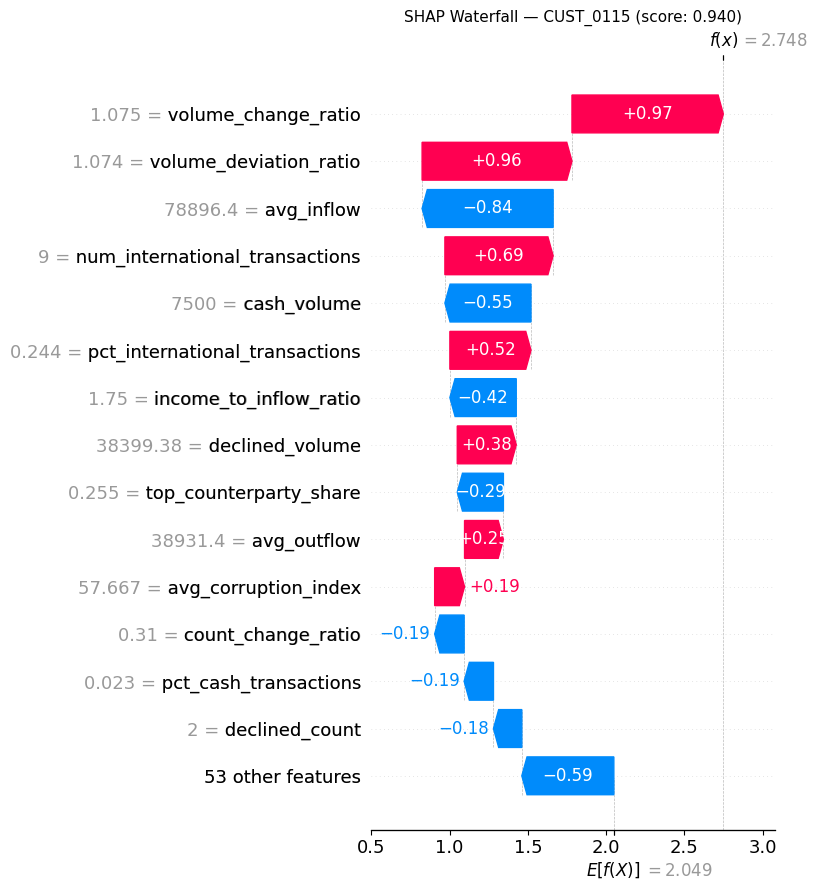

In [17]:
# ── SHAP Waterfall — most suspicious val customer ─────────────────────────────
# Show the full SHAP breakdown for the highest-risk customer in the val set.
# This is the kind of view the analyst workbench will display per flagged customer.

val_probs     = FINAL_MODEL.predict_proba(FINAL_X_VAL)[:, 1]
top_val_idx   = np.argmax(val_probs)            # index within val set
top_val_id    = df_base[df_base["split"]=="val"]["customer_id"].iloc[top_val_idx]
top_val_prob  = val_probs[top_val_idx]

print(f"Most suspicious val customer: {top_val_id}  (score: {top_val_prob:.3f})")

# SHAP waterfall plot for this single customer
# Shows which features drove the score up (+) or down (-)
global_val_idx = len(FINAL_X_TRAIN) + top_val_idx   # index in the all-customer array

shap.waterfall_plot(
    shap.Explanation(
        values     = shap_values[global_val_idx],
        base_values= explainer.expected_value,
        data       = X_all.iloc[global_val_idx].values,
        feature_names = X_all.columns.tolist()
    ),
    max_display = 15,
    show        = False
)
plt.title(f"SHAP Waterfall — {top_val_id} (score: {top_val_prob:.3f})", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_waterfall_top_customer.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Generate All Outputs

Per the modeling skill and workbench requirements, we need four output files:

| File | Rows | Description |
|---|---|---|
| `predictions.csv` | 500 | Test customers only — the panel submission |
| `all_predictions.csv` | 1,200 | All customers — for workbench queue display |
| `prediction_drivers.csv` | 3,600 | Top-3 SHAP drivers per customer |
| `results.csv` | ongoing | Model run log — already maintained above |

In [18]:
# ── Probabilities for all 1,200 customers ─────────────────────────────────────
all_probs = FINAL_MODEL.predict_proba(X_all)[:, 1]

all_predictions = pd.DataFrame({
    "customer_id"         : all_ids,
    "predicted_probability": all_probs
})

# ── predictions.csv — 500 test rows only ──────────────────────────────────────
test_mask    = df_base["split"] == "test"
test_cids    = df_base[test_mask]["customer_id"].values

predictions  = all_predictions[all_predictions["customer_id"].isin(test_cids)].copy()

# ── Validate predictions.csv before saving ────────────────────────────────────
assert len(predictions) == 500,                                    "Expected 500 test rows"
assert set(predictions.columns) == {"customer_id","predicted_probability"}, \
                                                                   "Wrong columns"
assert predictions["predicted_probability"].between(0, 1).all(),  "Probabilities out of range"
assert predictions["predicted_probability"].notna().all(),         "Null probabilities"
assert predictions["customer_id"].is_unique,                       "Duplicate customer IDs"
assert set(predictions["customer_id"]) == set(test_cids),          "Customer ID mismatch"

print("✓ All assertions passed")

# Save
predictions.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
all_predictions.to_csv(OUTPUT_DIR / "all_predictions.csv", index=False)

print(f"✓ predictions.csv     saved — {len(predictions)} rows")
print(f"✓ all_predictions.csv saved — {len(all_predictions)} rows")

# Score distribution summary
print(f"\nScore distribution (test set):")
print(predictions["predicted_probability"].describe().round(4).to_string())

✓ All assertions passed
✓ predictions.csv     saved — 500 rows
✓ all_predictions.csv saved — 1200 rows

Score distribution (test set):
count    500.0000
mean       0.0410
std        0.1515
min        0.0001
25%        0.0003
50%        0.0007
75%        0.0044
max        0.9949


In [19]:
# ── prediction_drivers.csv — top-3 SHAP per customer ─────────────────────────
print("Building prediction_drivers.csv...")

drivers_df = build_drivers(FINAL_MODEL, X_all, all_ids, top_n=3)
drivers_df.to_csv(OUTPUT_DIR / "prediction_drivers.csv", index=False)

print(f"✓ prediction_drivers.csv saved — {len(drivers_df)} rows ({len(all_ids)} customers × 3 drivers)")
print("\nSample — top customer:")
top_cid = all_predictions.sort_values("predicted_probability", ascending=False).iloc[0]["customer_id"]
print(drivers_df[drivers_df["customer_id"] == top_cid].to_string(index=False))

Building prediction_drivers.csv...
✓ prediction_drivers.csv saved — 3600 rows (1200 customers × 3 drivers)

Sample — top customer:
customer_id  rank           feature_name  feature_value  shap_value
  CUST_0756     1    volume_change_ratio       5.701614    1.120560
  CUST_0756     2           decline_rate       0.060606    0.819281
  CUST_0756     3 volume_deviation_ratio       6.052602    0.738101


## 10. Final Summary

Print a clean summary of what was built and where files are saved.

In [20]:
log_df = pd.read_csv(RESULTS_LOG)

print("\n" + "="*60)
print("NordikBank AML — Modeling Complete")
print("="*60)
print(f"\nFinal model   : {FINAL_NAME}")
print(f"Val AUC-ROC   : {log_df[log_df['model_name']==FINAL_NAME]['val_auc'].iloc[-1]:.4f}")
print(f"Val PR-AUC    : recorded in results.csv notes")
print(f"Base rate     : {y_train.mean():.1%} (train)")
print(f"scale_pos_wt  : {SPW:.1f}")

print(f"\nOutputs saved to: {OUTPUT_DIR.resolve()}")
for fname in ["predictions.csv", "all_predictions.csv",
              "prediction_drivers.csv", "results.csv",
              "shap_summary.png", "shap_waterfall_top_customer.png",
              "roc_comparison.png", "model1_feature_importance.png"]:
    fpath = OUTPUT_DIR / fname
    status = "✓" if fpath.exists() else "✗ MISSING"
    print(f"  {status}  {fname}")

print("\nResults log:")
print(log_df.to_string(index=False))


NordikBank AML — Modeling Complete

Final model   : XGBoost_tsfresh
Val AUC-ROC   : 0.8790
Val PR-AUC    : recorded in results.csv notes
Base rate     : 4.2% (train)
scale_pos_wt  : 22.8

Outputs saved to: C:\Users\jasmi\Documents\DATA SCIENCE\Semester 2\1. Webudvikling\Exam Project 2025\Accenture-AI-Case\context\nordikbank-modeling
  ✓  predictions.csv
  ✓  all_predictions.csv
  ✓  prediction_drivers.csv
  ✓  results.csv
  ✓  shap_summary.png
  ✓  shap_waterfall_top_customer.png
  ✓  roc_comparison.png
  ✓  model1_feature_importance.png

Results log:
          timestamp      model_name                             features_version  val_auc  train_auc  n_train  n_val  base_rate_train                                                                 notes
2026-05-01 15:59:08    XGBoost_base                             features_base_v1   0.8557        1.0      500    200            0.042 scale_pos_weight=22.8, max_depth=4, lr=0.05, n_est=300, PR-AUC=0.4552
2026-05-01 15:59:14 XGBoost_tsfre